# LSST SN Ia Simulation Pipeline

Forward-model SN Ia light curves using a DP2 CCDVisit/detector table with `lightcurvelynx`.

**Survey**: DP2 visit-detector table (`DP2_VISIT_DETECTOR_FILE`, the real DP2 `visit_detector.parquet`)  
**Model**: SALT3 via `SncosmoWrapperModel`  
**Filters**: u, g, r, i, z, y  
**Redshift**: volumetric rate (Frohmaier et al. 2019), z = 0.001–1.0  
**Parameters**: Asymmetric Gaussian priors (Nicolas et al. 2021) for x1 and c (no pzflow, no host galaxy)

## 1. Imports

## 0. Environment Setup

Set `LIGHTCURVELYNX_DATA_DIR` **before** importing lightcurvelynx — the download path is resolved at import time.  
Downloaded files (OpSim DB, passbands) will be stored in `./data/` inside this project directory.

In [1]:
# auto reload
%load_ext autoreload
%autoreload 2

In [2]:
# %pip install sfdmap2
# %pip install iminuit

In [3]:
# # setup dustmaps, run once
# from dustmaps.config import config
# config.reset()

In [4]:
import os
from pathlib import Path

# Store downloaded data inside this project so it travels with the repo checkout.
# Must be set before any lightcurvelynx imports (path is resolved at import time).
_data_dir = Path().resolve() / "data"
_data_dir.mkdir(exist_ok=True)
os.environ["LIGHTCURVELYNX_DATA_DIR"] = str(_data_dir)
print(f"LIGHTCURVELYNX_DATA_DIR = {_data_dir}")

LIGHTCURVELYNX_DATA_DIR = /home/midai/mdai/lightcurvelynx_rubin_dp2/data


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.stats import chi2
from nested_pandas import read_parquet
from joblib.externals.loky import get_reusable_executor
import sncosmo
from astropy.cosmology import Planck18
from astropy.coordinates import Distance

from lightcurvelynx.obstable.lsst_obstable import LSSTObsTable
from lightcurvelynx.utils.io_utils import read_sqlite_table
from lightcurvelynx.astro_utils.passbands import PassbandGroup
from lightcurvelynx.astro_utils.snia_utils import (
    DistModFromRedshift,
    X0FromDistMod,
    num_snia_per_redshift_bin,
    snia_volumetric_rates,
)
from lightcurvelynx.math_nodes.np_random import NumpyRandomFunc
from lightcurvelynx.math_nodes.scipy_random import SamplePDF
from lightcurvelynx.math_nodes.ra_dec_sampler import ObsTableUniformRADECSampler,ApproximateMOCSampler
from lightcurvelynx.models.sncosmo_models import SncosmoWrapperModel
from lightcurvelynx.simulate import simulate_lightcurves
from lightcurvelynx.utils.extrapolate import LinearDecayOnMag,ZeroPadding
from lightcurvelynx.astro_utils.dustmap import DustmapWrapper,SFDMap
from lightcurvelynx.effects.extinction import ExtinctionEffect
from lightcurvelynx.astro_utils.mag_flux import flux2mag

import lightcurvelynx
print(lightcurvelynx.__version__)

/home/midai/.conda/envs/lynx/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


0.5.2.dev5+g39303e74d


## 2. Simulation Configuration

In [6]:
SEED = 1024
RNG  = np.random.default_rng(SEED)

SKIP_SIM = True   # Set to True to skip simulation and load existing results from disk.
SKIP_LCFIT = False # Set to True to skip LC fitting and load existing results from disk.
FIT_Z = True # Fit redshift in SALT fit.
FIT_Z_SUFFIX = "_fitz" if FIT_Z else ""

# The DP2 CCDVisit/detector table has no field/program column, so DDF/WFD visits can't be
# selected by string match (unlike the opsim `observation_reason` column used in
# dp2_sims_ddf.ipynb). Instead, select/exclude by proximity to known DDF field centers.
SELECT_DDF_ONLY = False  # Set to True to keep only visits within DDF_RADIUS_DEG of a DDF field.
SELECT_WFD_ONLY = False  # Set to True to exclude visits within DDF_RADIUS_DEG of a DDF field.
assert not (SELECT_DDF_ONLY and SELECT_WFD_ONLY), "SELECT_DDF_ONLY and SELECT_WFD_ONLY are mutually exclusive."

OUTPUT_SUFFIX = "_ddf" if SELECT_DDF_ONLY else "_wfd" if SELECT_WFD_ONLY else ""  # Tag output filenames.

SIM_PARAMS = {
    # Cosmology
    "H0": 70.0,
    "Omega_m": 0.315,
    "w": -1.0,
    # Redshift range
    "zmin": 0.001,
    "zmax": 1.0,
    "znbins": 100,
    # Tripp relation coefficients
    "alpha": 0.15,
    "beta": 3.15,
    # SALT3 asymmetric Gaussian priors (Nicolas et al. 2021)
    "x1_mean": 0.973,  "x1_sigma_minus": 1.472, "x1_sigma_plus": 0.222,
    "c_mean": -0.054,  "c_sigma_minus":  0.043,  "c_sigma_plus":  0.101,
    "m_abs_mean": -19.3, "m_abs_sigma": 0.1,
    # Survey
    "filters": ["u", "g", "r", "i", "z", "y"],
    "sky_coverage": 18_000.0,  # LSST WFD footprint in deg²
    # The real DP2 visit_detector table covers ~5M rows; simulating the full expected
    # SN Ia count is impractical, so subsample down to a tractable number.
    "subsample_frac": 0.1,
}

## 3. Load LSST Visit Table

Loading the DP2 visit-detector table from `DP2_VISIT_DETECTOR_FILE`.

If `SELECT_DDF_ONLY` is `True`, visits are restricted to those within `DDF_RADIUS_DEG` of a
known Deep Drilling Field center (COSMOS, ECDFS, EDFS a/b, ELAIS-S1, XMM-LSS). If
`SELECT_WFD_ONLY` is `True`, those DDF visits are excluded instead, leaving only the wide-fast-deep
survey. The CCDVisit table has no `observation_reason`/field column to filter on directly, so
this selection is done by sky position instead.

In [7]:
DP2_VISIT_DETECTOR_FILE = "/rubin/lsdb_data/dp2/public-files/visit_detector.parquet"
dp2_visit_table = pd.read_parquet(DP2_VISIT_DETECTOR_FILE)

# LSST Deep Drilling Field centers (rubin_scheduler / rubin_sim definitions).
DDF_FIELDS = {
    "COSMOS":   (150.1167, 2.2058),
    "ECDFS":    (53.125,  -28.100),
    "EDFS_a":   (58.90,   -49.315),
    "EDFS_b":   (63.60,   -47.60),
    "ELAIS-S1": (9.45,    -44.00),
    "XMM-LSS":  (35.708,  -4.750),
}
DDF_RADIUS_DEG = 1.75  # matching radius around each DDF field center

def select_ddf_visits(visit_table, ra_col="ra", dec_col="dec"):
    from astropy.coordinates import SkyCoord
    import astropy.units as u

    visit_coords = SkyCoord(ra=visit_table[ra_col].values * u.deg, dec=visit_table[dec_col].values * u.deg)
    is_ddf = np.zeros(len(visit_table), dtype=bool)
    for ra, dec in DDF_FIELDS.values():
        field_coord = SkyCoord(ra=ra * u.deg, dec=dec * u.deg)
        is_ddf |= visit_coords.separation(field_coord).deg < DDF_RADIUS_DEG
    return is_ddf

if SELECT_DDF_ONLY:
    n_before = len(dp2_visit_table)
    dp2_visit_table = dp2_visit_table[select_ddf_visits(dp2_visit_table)]
    print(f"Selected {len(dp2_visit_table):,} DDF visits out of {n_before:,} total")
elif SELECT_WFD_ONLY:
    n_before = len(dp2_visit_table)
    dp2_visit_table = dp2_visit_table[~select_ddf_visits(dp2_visit_table)]
    print(f"Selected {len(dp2_visit_table):,} WFD visits out of {n_before:,} total (excluded DDF)")

obstable = LSSTObsTable.from_ccdvisit_table(dp2_visit_table, make_detector_footprint=True)
print(f"Visit table loaded: {len(obstable):,} observations")
print(f"MJD range: {obstable['time'].min():.1f} – {obstable['time'].max():.1f}")
print(f"Filters:    {sorted(obstable['filter'].unique())}")

/home/midai/mdai/lightcurvelynx/lightcurvelynx/src/lightcurvelynx/obstable/lsst_obstable.py:273: UserWarning: Found NaN values in critical column 'pixelScale'. Dropping rows with NaN values in this column.
  warnings.warn(
/home/midai/mdai/lightcurvelynx/lightcurvelynx/src/lightcurvelynx/obstable/lsst_obstable.py:273: UserWarning: Found NaN values in critical column 'seeing'. Dropping rows with NaN values in this column.
  warnings.warn(
/home/midai/mdai/lightcurvelynx/lightcurvelynx/src/lightcurvelynx/obstable/lsst_obstable.py:273: UserWarning: Found NaN values in critical column 'zeroPoint'. Dropping rows with NaN values in this column.
  warnings.warn(


Visit table loaded: 5,004,759 observations
MJD range: 60790.1 – 61047.4
Filters:    ['g', 'i', 'r', 'u', 'y', 'z']


In [8]:
obstable.head()

,detectorId,visitId,physical_filter,filter,ra,dec,pixel_scale,zenithDistance,exptime,zp_mag_adu,...,lrcdec,wcsCornerMaxOffset,wcsDetectorPointingResidual,wcsVisitPointingResidual,wcsPreliminaryDetectorPointingResidual,wcsPreliminaryVisitPointingResidual,radius,zp,psf_footprint,sky_bg_e
0,1,2025042400172,r_57,r,183.924159,6.983400,0.199324,37.089813,29.999916,32.158752,...,6.828384,0.170347,0.744071,6.553011,0.916436,6.759033,0.157980,0.311701,150.325357,2450.773193
1,2,2025042400172,r_57,r,184.119267,7.114777,0.199386,37.218884,29.999916,32.171349,...,6.959794,0.041369,0.706818,5.430327,0.743956,5.477780,0.158029,0.308106,152.484625,2506.839600
2,3,2025042400172,r_57,r,183.860867,6.658387,0.199382,36.765778,29.999916,32.168167,...,6.503267,0.030114,0.667091,6.370576,0.689754,6.432752,0.158026,0.309010,130.565136,2498.805908
3,4,2025042400172,r_57,r,184.056165,6.789660,0.199462,36.894409,29.999916,32.176689,...,6.634574,0.028227,0.661132,6.271190,0.670319,6.300598,0.158089,0.306594,120.875367,2506.594238
4,5,2025042400172,r_57,r,184.251453,6.921106,0.199489,37.024181,29.999916,32.180489,...,6.766038,0.034896,0.656864,5.191592,0.665656,5.237656,0.158111,0.305523,116.177034,2521.336914


In [9]:
sky_coverage = obstable.estimate_coverage(max_depth=8,use_footprint=False)    
# sky_coverage = 75
SIM_PARAMS["sky_coverage"] = sky_coverage
print(f"Estimated sky coverage: {sky_coverage:.0f} deg²")

Estimated sky coverage: 15961 deg²


(<Figure size 640x480 with 1 Axes>, <WCSAxes: >)

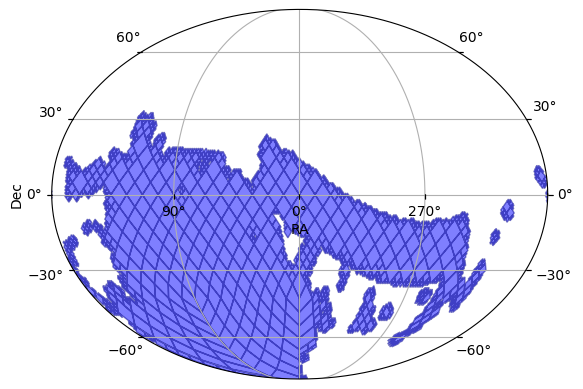

In [10]:
obstable.plot_footprint(depth=8,use_footprint=False)

## 4. Calculate Number of SNe to Simulate

Integrate the volumetric SN Ia rate over the survey volume and duration:
$$N = \int_{z_{\rm min}}^{z_{\rm max}} r_v(z)\,\frac{dV}{dz}\,\frac{dz}{1+z} \times \Omega \times T_{\rm survey}$$

In [11]:
t_min = float(obstable["time"].min())
t_max = float(obstable["time"].max())

survey_length = (t_max - t_min) / 365.25
print(f"Survey length = {survey_length:.2f} years")

solid_angle = SIM_PARAMS["sky_coverage"] * (np.pi / 180.0) ** 2
print(f"Solid angle   = {solid_angle:.4f} sr  ({SIM_PARAMS['sky_coverage']:,.0f} deg²)")

nsntotal, _ = num_snia_per_redshift_bin(
    SIM_PARAMS["zmin"],
    SIM_PARAMS["zmax"],
    znbins=1,
    solid_angle=solid_angle,
    vol_rate_function=snia_volumetric_rates,
    H0=SIM_PARAMS["H0"],
    Omega_m=SIM_PARAMS["Omega_m"],
)
nsn = int(nsntotal[0] * survey_length)
nsn = int(nsn * SIM_PARAMS["subsample_frac"])
print(f"Expected SNe Ia = {nsn:,}")

Survey length = 0.70 years
Solid angle   = 4.8621 sr  (15,961 deg²)
Expected SNe Ia = 131,875


## 5. Load LSST Passbands

In [12]:
passbands = PassbandGroup.from_preset("LSST", filters=SIM_PARAMS["filters"])
print(passbands)

PassbandGroup containing 6 passbands: LSST_u, LSST_g, LSST_r, LSST_i, LSST_z, LSST_y


## 6. Redshift Distribution (Volumetric Rate)

Use the Frohmaier et al. (2019) volumetric rate $r_v(z) = r_0\,(1+z)^\alpha$ to compute the
expected number of SNe Ia per redshift bin, then build an interpolated PDF for sampling.

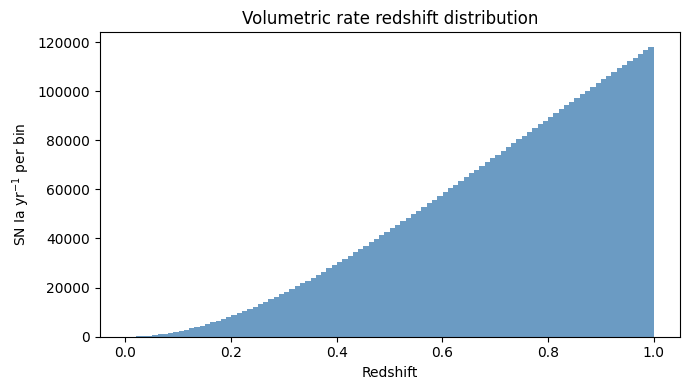

In [13]:
nsn_per_bin, z_mean = num_snia_per_redshift_bin(
    SIM_PARAMS["zmin"],
    SIM_PARAMS["zmax"],
    SIM_PARAMS["znbins"],
    H0=SIM_PARAMS["H0"],
    Omega_m=SIM_PARAMS["Omega_m"],
)
zpdf = interp1d(z_mean, nsn_per_bin, bounds_error=False, fill_value=0)

fig, ax = plt.subplots(figsize=(7, 4))
dz = (SIM_PARAMS["zmax"] - SIM_PARAMS["zmin"]) / SIM_PARAMS["znbins"]
ax.bar(z_mean, nsn_per_bin, width=dz, color="steelblue", alpha=0.8)
ax.set(xlabel="Redshift", ylabel="SN Ia yr$^{-1}$ per bin",
       title="Volumetric rate redshift distribution")
plt.tight_layout()
plt.show()

## 7. Build SN Ia Source Model

Parameter graph:
- **RA, Dec** — uniformly sampled from the observed LSST footprint via a MOC (`ApproximateMOCSampler`)
- **redshift** — drawn from the volumetric rate PDF (`SamplePDF`)
- **x1** — asymmetric Gaussian ($\mu=0.973$, $\sigma_-=1.472$, $\sigma_+=0.222$) [Nicolas et al. 2021]
- **c** — asymmetric Gaussian ($\mu=-0.054$, $\sigma_-=0.043$, $\sigma_+=0.101$) [Nicolas et al. 2021]
- **M_abs** — Gaussian($\mu=-19.3$, $\sigma=0.1$)
- **distmod** — computed from redshift via `DistModFromRedshift`
- **x0** — computed via the Tripp relation through `X0FromDistMod`

In [14]:
# RA/Dec: uniform over the obstable footprint (rejection sampling)
# radec = ObsTableUniformRADECSampler(obstable, node_label="radec")
moc = obstable.build_moc(max_depth=12)
radec = ApproximateMOCSampler(moc, node_label="radec")

# Redshift from volumetric rate PDF
z_func = SamplePDF(zpdf, node_label="redshift")

# Asymmetric Gaussian priors for x1 and c (Nicolas et al. 2021)
def asymmetric_gaussian_pdf(x, mu, sigma_minus, sigma_plus):
    sigma = np.where(x < mu, sigma_minus, sigma_plus)
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def x1_pdf(x):
    return asymmetric_gaussian_pdf(x, SIM_PARAMS["x1_mean"],
                                   SIM_PARAMS["x1_sigma_minus"], SIM_PARAMS["x1_sigma_plus"])

def c_pdf(c):
    return asymmetric_gaussian_pdf(c, SIM_PARAMS["c_mean"],
                                   SIM_PARAMS["c_sigma_minus"], SIM_PARAMS["c_sigma_plus"])

x1_func    = SamplePDF(x1_pdf, node_label="x1")
c_func     = SamplePDF(c_pdf,  node_label="c")
m_abs_func = NumpyRandomFunc("normal", loc=SIM_PARAMS["m_abs_mean"], scale=SIM_PARAMS["m_abs_sigma"])

# x0 via Tripp relation
distmod_func = DistModFromRedshift(
    z_func, H0=SIM_PARAMS["H0"], Omega_m=SIM_PARAMS["Omega_m"]
)
x0_func = X0FromDistMod(
    distmod=distmod_func,
    x1=x1_func,
    c=c_func,
    alpha=SIM_PARAMS["alpha"],
    beta=SIM_PARAMS["beta"],
    m_abs=m_abs_func,
    node_label="x0_func",
)

# Extrapolation settings
time_extrap_before = ZeroPadding()
time_extrap_after = LinearDecayOnMag(decay_rate=0.02, mag_thres=30.)
wave_extrap_before = ZeroPadding()
wave_extrap_after = ZeroPadding()

# Assemble the SALT3 source (no host galaxy)
source = SncosmoWrapperModel(
    "salt3",
    t0=NumpyRandomFunc("uniform", low=t_min, high=t_max),
    x0=x0_func,
    x1=x1_func,
    c=c_func,
    ra=radec.ra,
    dec=radec.dec,
    redshift=z_func,
    node_label="source",
    time_extrapolation=(time_extrap_before, time_extrap_after),
    wave_extrapolation=(wave_extrap_before, wave_extrap_after),
)

from dustmaps.sfd import SFDQuery
mwextinction = DustmapWrapper(SFDQuery(), ra=source.ra, dec=source.dec, node_label="mwext")
ext_effect = ExtinctionEffect(extinction_model="F99", ebv=mwextinction,
                              r_v=3.1, frame='observer', backend="dust_extinction")
source.add_effect(ext_effect)

print("Source model built successfully.")

Source model built successfully.


## 8. Run Simulation

In [15]:
if not SKIP_SIM:
    param_cols = [
        "source.t0",
        "source.x0",
        "source.x1",
        "source.c",
        "source.redshift",
        "source.ra",
        "source.dec",
        "x0_func.distmod",
    ]
    obstable_save_cols = ["zp"]

    NJOBS = 8
    BATCH_SIZE = 3000
    executor = get_reusable_executor(max_workers=4)
    lightcurves = simulate_lightcurves(
        model=source,
        num_samples=nsn,
        survey_info=obstable,
        passbands=passbands,
        param_cols=param_cols,
        obstable_save_cols=obstable_save_cols,
        rng=RNG,
        num_jobs=NJOBS,
        batch_size=BATCH_SIZE,
        executor=executor,
    )
    print(f"Simulated {len(lightcurves):,} SNe Ia")
    lightcurves.head()

## 9. Save Results

In [16]:
if not SKIP_SIM:
    from pathlib import Path
    output_path = Path(f"outputs/lsst_snia_dp2_visitdetector{OUTPUT_SUFFIX}_results.parquet")
    output_path.parent.mkdir(exist_ok=True)
    lightcurves.to_parquet(output_path)
    print(f"Saved to {output_path}")

In [17]:
lightcurves = read_parquet(f"outputs/lsst_snia_dp2_visitdetector{OUTPUT_SUFFIX}_results.parquet")

## 10. Apply Selections

In [18]:
# calculate detection flag
lightcurves = lightcurves.drop(columns=["params"])
lightcurves = lightcurves.dropna(subset=['lightcurve'])

print("Before applying detection: nsn=", len(lightcurves))
lightcurves['lightcurve.snr'] = lightcurves['lightcurve.flux']/lightcurves['lightcurve.fluxerr']
detection_snr_thres = 5.
lightcurves['lightcurve.detection_flag'] = lightcurves['lightcurve.snr'] > detection_snr_thres

# drop saturation
lightcurves_after_drop_sat = lightcurves.query("lightcurve.is_saturated==False").dropna(subset=['lightcurve'])
print("After droppoing saturation: nsn=", len(lightcurves_after_drop_sat))

lightcurves_after_detection = lightcurves_after_drop_sat.query("lightcurve.detection_flag == True").dropna(subset=['lightcurve'])
print("After applying detection: nsn=", len(lightcurves_after_detection))

Before applying detection: nsn= 128381
After droppoing saturation: nsn= 128381
After applying detection: nsn= 21331


In [19]:
# define quality cuts for lightcurves
def lc_quality_cuts(flux,mjd,filter,z,t0,n_phases=7, n_before_peak=2, n_after_peak=3, n_bands=2):
    phases = np.floor((mjd - t0)/(1. + z))
    unique_phases,unique_idx = np.unique(phases,return_index=True)
    good_idx = (unique_phases >= -10) & (unique_phases<=40)
    pass_cut = len(unique_phases[good_idx]) >= n_phases
    if np.sum(good_idx) == 0:
        return {"pass_quality_cuts": False}
    pass_before = np.sum(unique_phases[good_idx] < 0) >= n_before_peak
    pass_after = np.sum(unique_phases[good_idx] > 0) >= n_after_peak
    pass_cut = len(unique_phases[good_idx]) >= n_phases
    pass_cut &= pass_before
    pass_cut &= pass_after
    pass_cut &= len(np.unique(filter[unique_idx][good_idx])) >= n_bands
    return {"pass_quality_cuts": pass_cut}

In [20]:
pass_quality_cut = lightcurves_after_detection.map_rows(
    lc_quality_cuts,
    columns=["lightcurve.flux", "lightcurve.mjd", "lightcurve.filter", "z", "t0"],
    row_container="args"
)
idx = pass_quality_cut.query("pass_quality_cuts == True").index
lightcurves_after_quality_cut = lightcurves_after_detection.loc[idx]
print("After quality cuts: nsn=", len(lightcurves_after_quality_cut))

lightcurves["pass_quality_cuts"] = False
lightcurves.loc[idx,"pass_quality_cuts"] = True

After quality cuts: nsn= 671


In [21]:
def count_duplicate_mjd(mjd):
    unique_mjd, counts = np.unique(mjd, return_counts=True)
    num_duplicates = np.sum(counts > 1)
    return num_duplicates
ndf = lightcurves_after_quality_cut.map_rows(count_duplicate_mjd, columns=["lightcurve.mjd"], row_container="args")
ndf.loc[ndf[0]>0] if len(ndf) > 0 else ndf

,0


## 11. Diagnostics

Quick sanity checks on the simulated population.

In [22]:
results = lightcurves_after_quality_cut

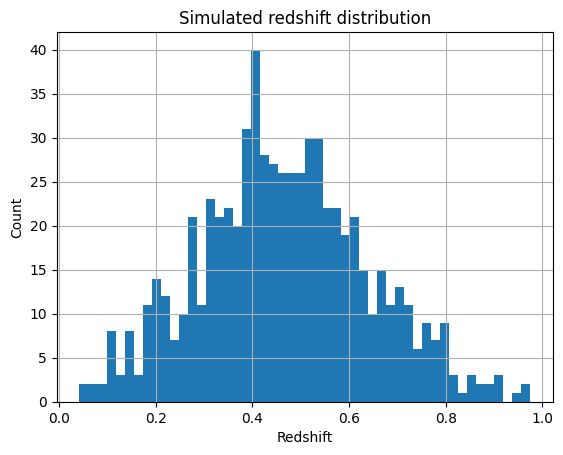

In [23]:
# redshift distribution of simulated SNe
fig, ax = plt.subplots()
results["source_redshift"].hist(bins=50, ax=ax)
ax.set(xlabel="Redshift", ylabel="Count", title="Simulated redshift distribution")
plt.show()

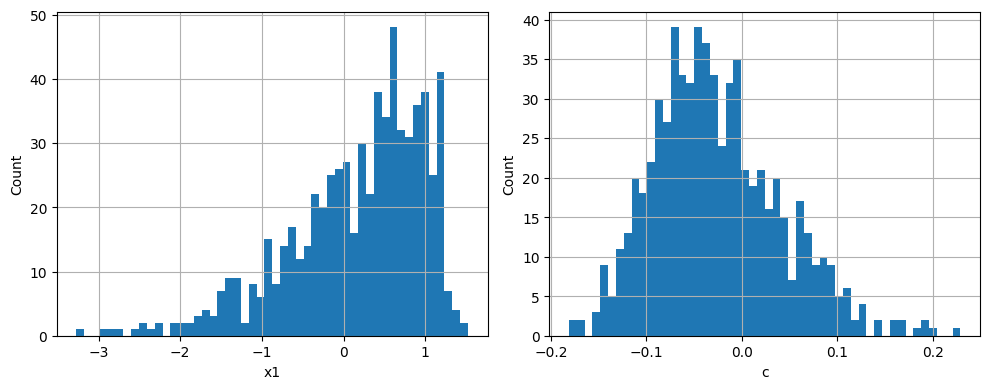

In [24]:
# x1 and c distributions
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
results["source_x1"].hist(bins=50, ax=axes[0])
axes[0].set(xlabel="x1", ylabel="Count")
results["source_c"].hist(bins=50, ax=axes[1])
axes[1].set(xlabel="c", ylabel="Count")
plt.tight_layout()
plt.show()

             mjd filter         flux     fluxerr  flux_perfect  survey_idx  \
0   60848.226866      r  1858.546143  268.156031   2049.081447           0   
1   60857.381853      i  2985.769353  269.303744   3156.640612           0   
2   60858.162655      r  3418.416653  126.432913   3264.650380           0   
3   60858.215237      r  3230.357606  153.390145   3264.972788           0   
4   60860.287311      r  3400.560401   83.368329   3261.344801           0   
5   60861.349441      i  2877.990579  296.421889   3211.812843           0   
6   60861.373235      z  4878.384477  541.912493   3670.986706           0   
7   60863.096790      i  3512.430371  439.268337   3198.904662           0   
8   60863.099025      i  3455.486466  463.133357   3198.864565           0   
9   60863.122995      z  3913.405731  705.261861   3699.422756           0   
10  60864.088091      i  2990.445418  501.366251   3176.050516           0   
11  60865.039636      z  5127.940786  715.662941   3655.846023  

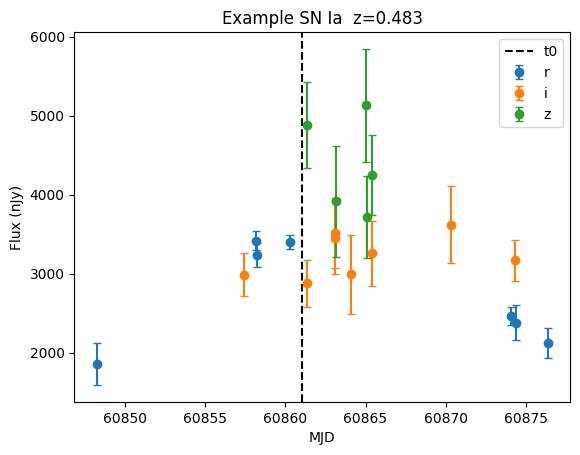

In [25]:
# example light curve for a single SN
sn = results.iloc[np.random.choice(len(results))]
lc = sn["lightcurve"]
print(lc)
for band in SIM_PARAMS["filters"]:
    mask = lc["filter"] == band
    mask &= (lc["mjd"] - sn["source_t0"])/(1. + sn["source_redshift"]) > -20  # only show points within 20 days before t0
    mask &= (lc["mjd"] - sn["source_t0"])/(1. + sn["source_redshift"]) < 100   # only show points within 20 days after t0
    if mask.any():
        plt.errorbar(lc["mjd"][mask], lc["flux"][mask], lc["fluxerr"][mask],
                     fmt="o", label=band, capsize=3)
plt.axvline(sn["source_t0"], ls="--", color="k", label="t0")
plt.legend()
plt.xlabel("MJD")
plt.ylabel("Flux (nJy)")
plt.title(f'Example SN Ia  z={sn["source_redshift"]:.3f}')
plt.show()

In [26]:
def infer_z_from_peakmag(row):
    peakflux = np.max(row)
    peakmag = flux2mag(peakflux)
    z = Distance(distmod = peakmag + 19).compute_z(cosmology=Planck18).value
    return z

In [27]:
# append system path 

from utils.lcfit import fit_single_lc  

def fit_single_lc_w_cond(lc,
                         bounds={"x1": (-4,4),
                                 "c": (-0.4,0.4),},
                         phase_range=(-10,40),
                         modelcov=False):
    return fit_single_lc(lc,mpbounds=bounds,phase_range=phase_range,modelcov=modelcov)

In [28]:
lc_to_fit = lightcurves_after_quality_cut.iloc[0:]

In [29]:
lc_to_fit = lc_to_fit.map_rows(infer_z_from_peakmag, columns=["lightcurve.flux"], row_container="args",
                     output_names=["z_est"], append_columns=True)

In [30]:
res = fit_single_lc_w_cond(lc_to_fit.iloc[0])
res

success        1.0
ncall        162.0
             ...  
id           419.0
fit_error      NaN
Length: 54, dtype: float64

In [31]:
%%time
if not SKIP_LCFIT:
    executor = get_reusable_executor(max_workers=10, kill_workers=True)
    futures = [executor.submit(fit_single_lc_w_cond, row) for _index, row in lc_to_fit.iterrows()]
    fit_results = [f.result() for f in futures]
    result_df = pd.DataFrame(fit_results)

CPU times: user 2.45 s, sys: 107 ms, total: 2.55 s
Wall time: 2min 11s


In [32]:
if not SKIP_LCFIT:
    result_df.to_csv(f"outputs/lsst_snia_dp2_visitdetector{OUTPUT_SUFFIX}_lcfit_results{FIT_Z_SUFFIX}.csv", index=True)
    print(f"Saved {len(result_df)} LC fit results")

Saved 671 LC fit results


In [33]:
result_df = pd.read_csv(f"outputs/lsst_snia_dp2_visitdetector{OUTPUT_SUFFIX}_lcfit_results{FIT_Z_SUFFIX}.csv")

In [34]:
saltparcuts = (result_df.x1 > -3) & (result_df.x1 < 3)
saltparcuts &= (result_df.c > -0.3) & (result_df.c < 0.3)
saltparcuts &= (result_df.success == True)
saltparcuts &= (result_df.t0_err < 1)
saltparcuts &= (result_df.x1_err < 1)
saltparcuts &= (result_df.c_err < 0.1)
p_value = 1 - chi2.cdf(result_df.chisq, df=result_df.ndof)
saltparcuts &= p_value > 1e-7

In [35]:
result_df[saltparcuts]

,Unnamed: 0,success,ncall,chisq,ndof,z,z_err,t0,t0_err,x0,...,c_c_cov,c_mwebv_cov,mwebv_z_cov,mwebv_t0_cov,mwebv_x0_cov,mwebv_x1_cov,mwebv_c_cov,mwebv_mwebv_cov,id,fit_error
1,1,1.0,105.0,17.755486,15.0,0.211810,0.003754,60873.655283,0.089463,0.000121,...,0.000078,0.0,0.0,0.0,0.0,0.0,0.0,0.0,537.0,NaN
2,2,1.0,124.0,20.172753,26.0,0.236759,0.011912,60876.246490,0.263669,0.000049,...,0.000466,0.0,0.0,0.0,0.0,0.0,0.0,0.0,624.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
669,669,1.0,247.0,109.084920,109.0,0.514889,0.022079,60869.911831,0.342489,0.000009,...,0.003146,0.0,0.0,0.0,0.0,0.0,0.0,0.0,131670.0,NaN
670,670,1.0,188.0,28.558038,25.0,0.383724,0.007254,60855.098170,0.167884,0.000024,...,0.000332,0.0,0.0,0.0,0.0,0.0,0.0,0.0,131784.0,NaN


<Axes: >

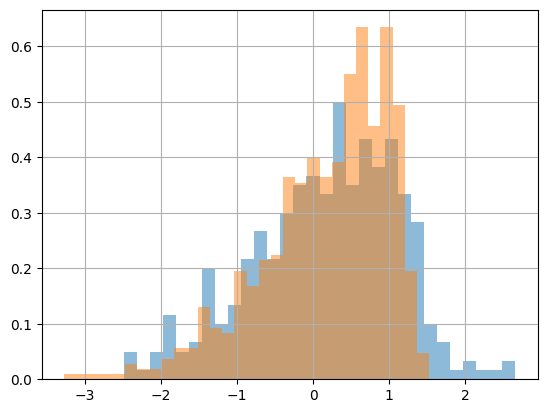

In [36]:
result_df[saltparcuts].x1.hist(bins=30,alpha=0.5,density=True)
lightcurves_after_quality_cut.source_x1.hist(bins=30,alpha=0.5,density=True)

<Axes: >

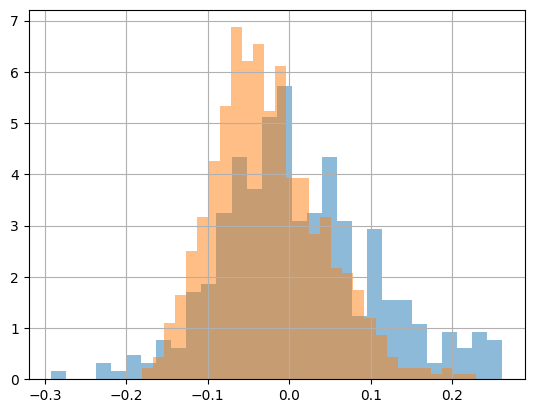

In [37]:
result_df[saltparcuts].c.hist(bins=30,alpha=0.5,density=True)
lightcurves_after_quality_cut.source_c.hist(bins=30,alpha=0.5,density=True)

      id          ra       dec  nobs            t0         z     source_t0  \
537  537  331.079605 -4.883266    28  60873.630026  0.204311  60873.630026   

     source_x0  source_x1  source_c  source_redshift   source_ra  source_dec  \
537   0.000123   0.253944 -0.027953         0.204311  331.079605   -4.883266   

     x0_func_distmod                                         lightcurve  
537        40.003151  [{mjd: 60857.309095, filter: 'r', flux: 4744.4...  


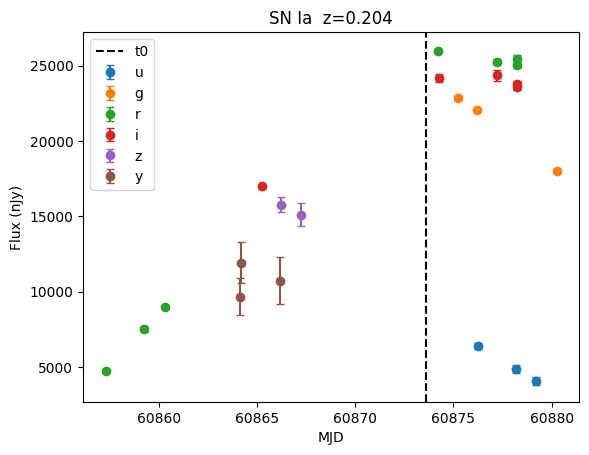

      id          ra        dec  nobs            t0         z     source_t0  \
624  624  314.367579 -18.949432    58  60876.154146  0.214384  60876.154146   

     source_x0  source_x1  source_c  source_redshift   source_ra  source_dec  \
624    0.00005  -0.220737  0.116149         0.214384  314.367579  -18.949432   

     x0_func_distmod                                         lightcurve  
624        40.120026  [{mjd: 60858.255269, filter: 'r', flux: 1252.9...  


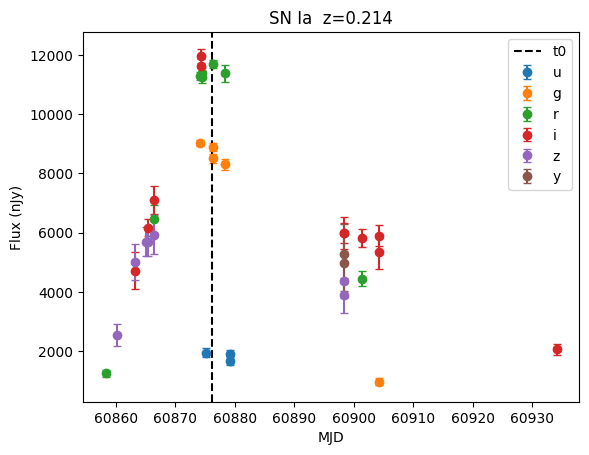

      id          ra        dec  nobs            t0         z     source_t0  \
705  705  114.131361 -67.301527    27  61013.931935  0.464774  61013.931935   

     source_x0  source_x1  source_c  source_redshift   source_ra  source_dec  \
705   0.000016  -0.350364 -0.037934         0.464774  114.131361  -67.301527   

     x0_func_distmod                                         lightcurve  
705        42.060823  [{mjd: 60997.304184, filter: 'r', flux: 967.32...  


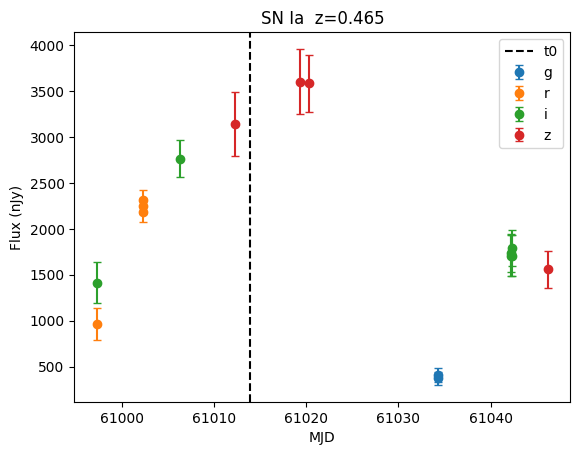

        id          ra       dec  nobs            t0         z     source_t0  \
1413  1413  317.143042 -22.25653    47  60873.788532  0.577428  60873.788532   

      source_x0  source_x1  source_c  source_redshift   source_ra  source_dec  \
1413   0.000018   0.857266 -0.181106         0.577428  317.143042   -22.25653   

      x0_func_distmod                                         lightcurve  
1413        42.625402  [{mjd: 60847.264268, filter: 'r', flux: 625.35...  


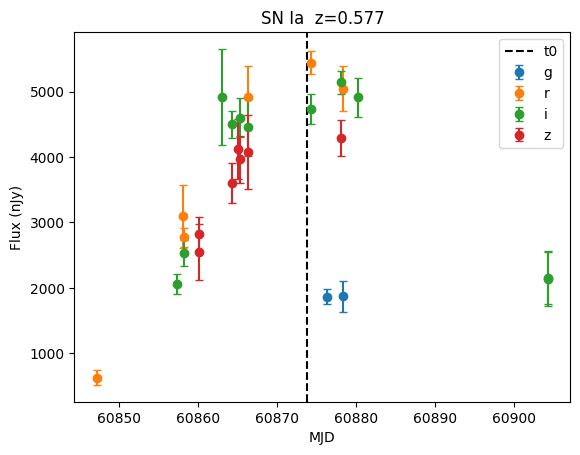

        id          ra        dec  nobs           t0        z    source_t0  \
1505  1505  307.633292 -14.838147    57  60859.39181  0.40448  60859.39181   

      source_x0  source_x1  source_c  source_redshift   source_ra  source_dec  \
1505   0.000031   1.180404 -0.084189          0.40448  307.633292  -14.838147   

      x0_func_distmod                                         lightcurve  
1505        41.703726  [{mjd: 60847.285711, filter: 'i', flux: 4233.1...  


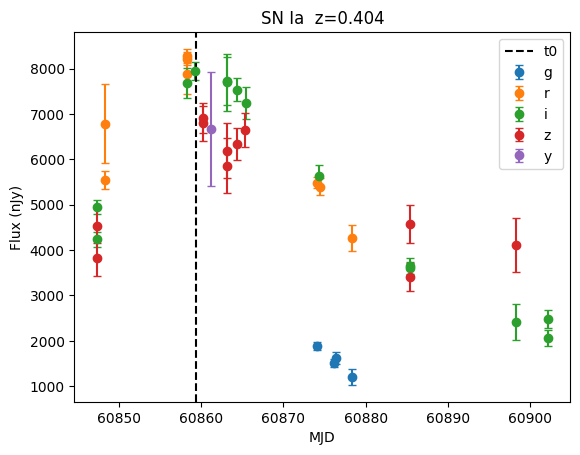

        id          ra       dec  nobs            t0         z     source_t0  \
1928  1928  331.111105 -9.318966    48  60876.824276  0.484955  60876.824276   

      source_x0  source_x1  source_c  source_redshift   source_ra  source_dec  \
1928   0.000016    0.22542   -0.0665         0.484955  331.111105   -9.318966   

      x0_func_distmod                                         lightcurve  
1928        42.170764  [{mjd: 60857.310979, filter: 'r', flux: 994.29...  


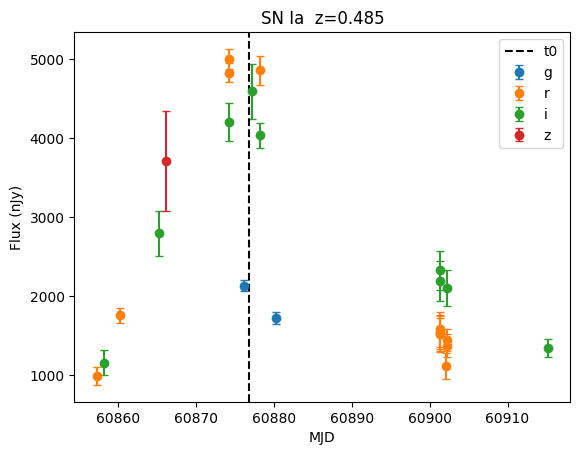

        id          ra        dec  nobs            t0         z     source_t0  \
2133  2133  340.889814 -12.109575    57  60866.680531  0.471805  60866.680531   

      source_x0  source_x1  source_c  source_redshift   source_ra  source_dec  \
2133   0.000018   0.762116 -0.040756         0.471805  340.889814  -12.109575   

      x0_func_distmod                                         lightcurve  
2133         42.09962  [{mjd: 60857.340952, filter: 'r', flux: 4158.5...  


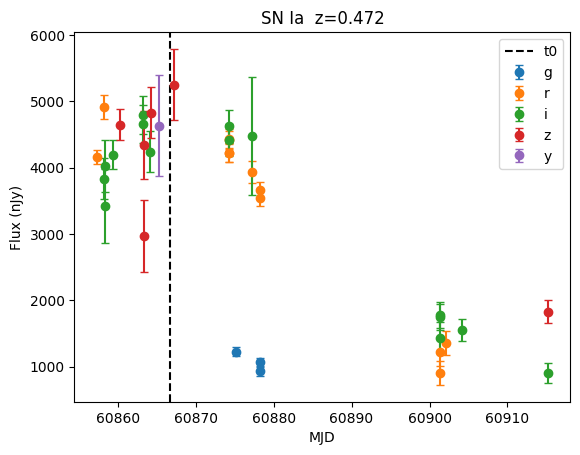

        id          ra       dec  nobs           t0         z    source_t0  \
2146  2146  346.746841 -4.786361    65  60883.41752  0.400543  60883.41752   

      source_x0  source_x1  source_c  source_redshift   source_ra  source_dec  \
2146   0.000017  -0.085991  0.029876         0.400543  346.746841   -4.786361   

      x0_func_distmod                                         lightcurve  
2146        41.678724  [{mjd: 60874.284119, filter: 'r', flux: 3450.3...  


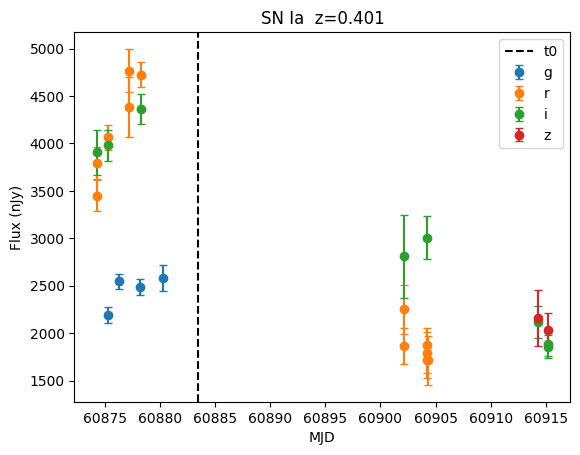

        id        ra        dec  nobs            t0         z     source_t0  \
2223  2223  63.48238 -48.490466   156  60870.573793  0.283486  60870.573793   

      source_x0  source_x1  source_c  source_redshift  source_ra  source_dec  \
2223   0.000048  -0.147917  0.012715         0.283486   63.48238  -48.490466   

      x0_func_distmod                                         lightcurve  
2223        40.807273  [{mjd: 60868.339863, filter: 'g', flux: 9693.7...  


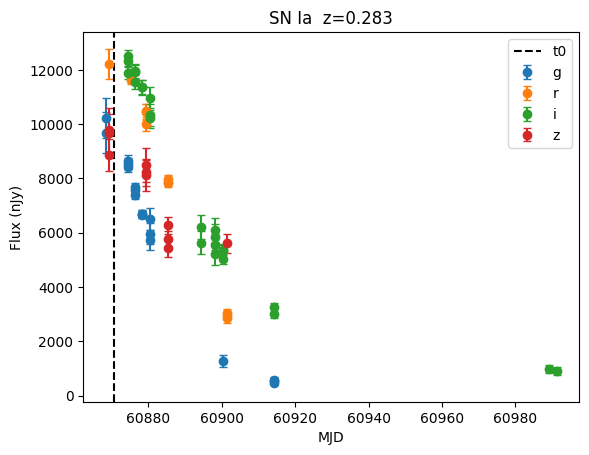

        id          ra        dec  nobs            t0         z     source_t0  \
2486  2486  322.317918 -22.738787    25  60858.753342  0.658671  60858.753342   

      source_x0  source_x1  source_c  source_redshift   source_ra  source_dec  \
2486   0.000008   1.146189 -0.042913         0.658671  322.317918  -22.738787   

      x0_func_distmod                                         lightcurve  
2486        42.971405  [{mjd: 60847.242275, filter: 'i', flux: 1632.2...  


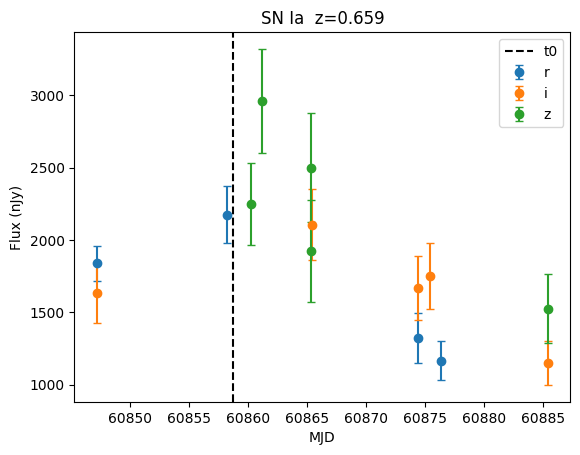

In [38]:
# plot all light curves pass all cuts
max_number = 10
for i in range(min(len(result_df[saltparcuts]), max_number)):
    sn = results.loc[results.id == int(result_df[saltparcuts].iloc[i].id)]
    print(sn)
    lc = sn["lightcurve"]
    # print(lc)
    for band in SIM_PARAMS["filters"]:
        mask = lc["filter"] == band
        mask &= (lc["mjd"] - sn["source_t0"])/(1. + sn["source_redshift"]) > -20  # only show points within 20 days before t0
        mask &= (lc["mjd"] - sn["source_t0"])/(1. + sn["source_redshift"]) < 100   # only show points within 20 days after t0
        if mask.any():
            plt.errorbar(lc["mjd"][mask], lc["flux"][mask], lc["fluxerr"][mask],
                        fmt="o", label=band, capsize=3)
    plt.axvline(sn["source_t0"].values[0], ls="--", color="k", label="t0")
    plt.legend()
    plt.xlabel("MJD")
    plt.ylabel("Flux (nJy)")
    plt.title(f'SN Ia  z={sn["source_redshift"].values[0]:.3f}')
    plt.show()

### Sky Distribution Before / After Cuts

Compare the RA/Dec distribution of the full simulated population against the SNe that
survive detection, light-curve quality cuts, and SALT parameter cuts.

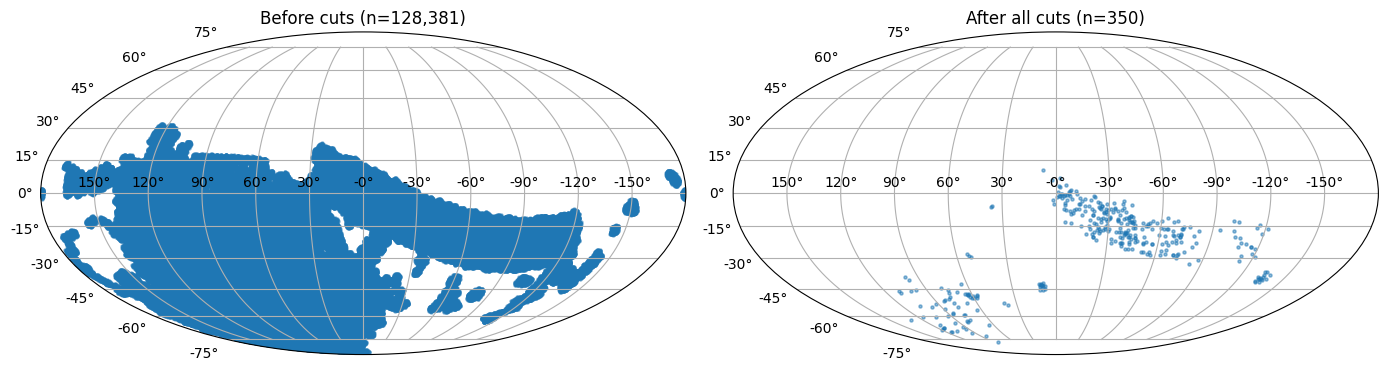

In [39]:
final_selection = results.loc[results.id.isin(result_df.loc[saltparcuts, "id"])]

def plot_skymap(ax, ra_deg, dec_deg, title):
    ra_wrapped = np.where(ra_deg > 180, ra_deg - 360, ra_deg)
    # Mirror RA so it increases right-to-left (standard sky-map convention); Mollweide axes
    # don't support invert_xaxis(), so negate the data and relabel the ticks instead.
    ax.scatter(-np.deg2rad(ra_wrapped), np.deg2rad(dec_deg), s=5, alpha=0.5)
    ax.set_title(title)
    ax.grid(True)
    ax.set_xticklabels([f"{-np.rad2deg(t):.0f}°" for t in ax.get_xticks()])

fig, axes = plt.subplots(1, 2, figsize=(14, 6), subplot_kw={"projection": "mollweide"})
plot_skymap(axes[0], lightcurves["source_ra"].values, lightcurves["source_dec"].values,
            f"Before cuts (n={len(lightcurves):,})")
plot_skymap(axes[1], final_selection["source_ra"].values, final_selection["source_dec"].values,
            f"After all cuts (n={len(final_selection):,})")
plt.tight_layout()
plt.show()